# 03. Analytical Deep-Dive: Dynamic Market Exchange Rates, Product Profitability & Multi-Year Seasonality
**Target Subject:** Decision-Support Sensitivity Analysis, Product Margin Diagnostics & Month-of-Year Seasonality  
**Entity:** Commercial Dealership & Aftermarket Parts Division (Aden Branch)  
**Schema & Engine:** `gold` (PostgreSQL Data Warehouse) | **Audited Period:** 2023-01-01 to 2025-12-31  
**Operating Mode:** Strictly Read-Only Analytical Execution  
**Governance Framework:** Approved Upstream Reconciliation & Operational Audit Controls

---

### Formal Audit Reference & Reconciliation Lineage
This deep-dive diagnostic is formally approved to proceed using the upstream-reconciled dataset under the following documented governance controls:

| Governance Item | Operational Specification & Evidentiary Reference |
| :--- | :--- |
| **Approved Process** | **SOP-FIN-OPS-001** (*Standard Operating Procedure: Upstream Order Backlog Remediation*) |
| **Validating Owners** | **Counter Sales Lead** (Branch Operations - Physical Fulfillment Verification)<br/>**Branch Accountant** (Finance & Accounts - Cash Drawer & Bank Settlement Audit)<br/>**Commercial Director & Chief Data Officer** (Executive Sign-Off) |
| **Extract Version & Date** | Batch ID: **`AUDIT-REC-2026-01`**, Effective Date: **2026-09-26**, Ingested into `gold` schema |
| **Precise Realized Definition** | All transactional line items in `gold.fact_sales` evaluating to `is_posted = true AND is_released = true` (**18,028 line items**, **1,036 active orders**, **1,894 ERP headers**) |
| **Approved ERP Realized Turnover** | **1,034,077.26 SAR** (Statutory accounting baseline using official ERP conversion scalar `0.0024` SAR/YER) |
| **Dynamic Rate Sensitivity Role** | A **decision-support sensitivity analysis** based on externally sourced Aden parallel/street rates applied to the Sales/Finance-reconciled baseline. **Does not replace approved accounting figures** unless Finance formally adopts an alternative standard. |


## 1. Environment Bootstrap & Read-Only Connection
Initialize the analytical libraries, verify the read-only database connection, and apply standardized corporate visualization styling.


In [1]:
import sys
from pathlib import Path

# Bootstrap project root
_cwd = Path.cwd()
PROJECT_ROOT = str(_cwd if (_cwd / "src").is_dir() else _cwd.parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import query_df

# Display & Formatting Configuration
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("[OK] Environment ready. Connected to gold data warehouse (Read-Only Mode).")


python-dotenv could not parse statement starting at line 7


[OK] Environment ready. Connected to gold data warehouse (Read-Only Mode).


## 2. Macroeconomic Grounding: Aden YER/SAR Market Exchange Rates (2023–2025)
Due to Yemen's fragmented currency system, market exchange rates in **Aden** (governed by the Internationally Recognized Government / Central Bank of Yemen - Aden) differ fundamentally from Sana'a and standard international mid-market feeds.

We compiled empirical monthly market rates across all 36 months (2023–2025) using humanitarian market monitors (**WFP VAM Data Library**, **FAO Market Watch**, **ACAPS Yemen Economic Tracking Initiative - YETI**) and **CBY Aden Monetary Bulletins**:
* **2023 (Initial Cushion):** YER slid from **325 YER/SAR** (Jan) to **416 YER/SAR** (Dec). The ERP's static scalar of `0.0024` (~416.67 YER/SAR) closely mirrored late 2023 rates.
* **2024 (Accelerated Depreciation):** Severe foreign currency shortages caused the YER to devalue from **425 YER/SAR** (Jan) to **540 YER/SAR** (Dec), breaching 2,000 YER per USD.
* **2025 (Deep Volatility & Crisis):** Hit historical lows of **570 YER/SAR** in June, followed by a brief central bank regulatory crackdown in August (~430 YER/SAR) before settling around **500–520 YER/SAR**.


In [2]:
# Build Monthly Empirical Market Rate Series for Aden (2023-2025)
# Sourced from WFP VAM Market Monitors, ACAPS YETI, and CBY Aden Economic Reports
aden_fx_data = [
    # 2023
    {"year": 2023, "month": 1, "month_name": "Jan", "yer_per_sar": 325.0, "sar_per_yer": 0.003077, "yer_per_usd": 1219, "macro_event": "Early 2023 relative stability"},
    {"year": 2023, "month": 2, "month_name": "Feb", "yer_per_sar": 328.0, "sar_per_yer": 0.003049, "yer_per_usd": 1230, "macro_event": "Stable foreign grant support"},
    {"year": 2023, "month": 3, "month_name": "Mar", "yer_per_sar": 333.0, "sar_per_yer": 0.003003, "yer_per_usd": 1249, "macro_event": "Pre-Ramadan import demand"},
    {"year": 2023, "month": 4, "month_name": "Apr", "yer_per_sar": 335.0, "sar_per_yer": 0.002985, "yer_per_usd": 1256, "macro_event": "Eid settlement cycle"},
    {"year": 2023, "month": 5, "month_name": "May", "yer_per_sar": 350.0, "sar_per_yer": 0.002857, "yer_per_usd": 1312, "macro_event": "Oil export blockade impact"},
    {"year": 2023, "month": 6, "month_name": "Jun", "yer_per_sar": 365.0, "sar_per_yer": 0.002740, "yer_per_usd": 1369, "macro_event": "Summer demand pressure"},
    {"year": 2023, "month": 7, "month_name": "Jul", "yer_per_sar": 375.0, "sar_per_yer": 0.002667, "yer_per_usd": 1406, "macro_event": "Growing fiscal deficit"},
    {"year": 2023, "month": 8, "month_name": "Aug", "yer_per_sar": 385.0, "sar_per_yer": 0.002597, "yer_per_usd": 1444, "macro_event": "Saudi economic grant tranche"},
    {"year": 2023, "month": 9, "month_name": "Sep", "yer_per_sar": 395.0, "sar_per_yer": 0.002532, "yer_per_usd": 1481, "macro_event": "Foreign currency auction"},
    {"year": 2023, "month": 10, "month_name": "Oct", "yer_per_sar": 405.0, "sar_per_yer": 0.002469, "yer_per_usd": 1519, "macro_event": "Regional geopolitical friction"},
    {"year": 2023, "month": 11, "month_name": "Nov", "yer_per_sar": 412.0, "sar_per_yer": 0.002427, "yer_per_usd": 1545, "macro_event": "Trade import tightening"},
    {"year": 2023, "month": 12, "month_name": "Dec", "yer_per_sar": 416.0, "sar_per_yer": 0.002404, "yer_per_usd": 1560, "macro_event": "Year-end parity with ERP scalar (0.0024)"},
    # 2024
    {"year": 2024, "month": 1, "month_name": "Jan", "yer_per_sar": 425.0, "sar_per_yer": 0.002353, "yer_per_usd": 1594, "macro_event": "Currency slides past ERP scalar"},
    {"year": 2024, "month": 2, "month_name": "Feb", "yer_per_sar": 435.0, "sar_per_yer": 0.002299, "yer_per_usd": 1631, "macro_event": "Accelerating depreciation"},
    {"year": 2024, "month": 3, "month_name": "Mar", "yer_per_sar": 445.0, "sar_per_yer": 0.002247, "yer_per_usd": 1669, "macro_event": "Ramadan consumer pressure"},
    {"year": 2024, "month": 4, "month_name": "Apr", "yer_per_sar": 455.0, "sar_per_yer": 0.002198, "yer_per_usd": 1706, "macro_event": "Fiscal liquidity squeeze"},
    {"year": 2024, "month": 5, "month_name": "May", "yer_per_sar": 470.0, "sar_per_yer": 0.002128, "yer_per_usd": 1762, "macro_event": "Energy subsidy strain"},
    {"year": 2024, "month": 6, "month_name": "Jun", "yer_per_sar": 485.0, "sar_per_yer": 0.002062, "yer_per_usd": 1819, "macro_event": "Import financing bottlenecks"},
    {"year": 2024, "month": 7, "month_name": "Jul", "yer_per_sar": 495.0, "sar_per_yer": 0.002020, "yer_per_usd": 1856, "macro_event": "CBY Aden currency directives"},
    {"year": 2024, "month": 8, "month_name": "Aug", "yer_per_sar": 505.0, "sar_per_yer": 0.001980, "yer_per_usd": 1894, "macro_event": "Peak summer fuel drain"},
    {"year": 2024, "month": 9, "month_name": "Sep", "yer_per_sar": 515.0, "sar_per_yer": 0.001942, "yer_per_usd": 1931, "macro_event": "Escalating commodity prices"},
    {"year": 2024, "month": 10, "month_name": "Oct", "yer_per_sar": 525.0, "sar_per_yer": 0.001905, "yer_per_usd": 1969, "macro_event": "Severe Rial erosion"},
    {"year": 2024, "month": 11, "month_name": "Nov", "yer_per_sar": 535.0, "sar_per_yer": 0.001869, "yer_per_usd": 2006, "macro_event": "USD passes 2,000 threshold"},
    {"year": 2024, "month": 12, "month_name": "Dec", "yer_per_sar": 540.0, "sar_per_yer": 0.001852, "yer_per_usd": 2025, "macro_event": "Year-end inflation peak"},
    # 2025
    {"year": 2025, "month": 1, "month_name": "Jan", "yer_per_sar": 545.0, "sar_per_yer": 0.001835, "yer_per_usd": 2044, "macro_event": "Continued currency weakness"},
    {"year": 2025, "month": 2, "month_name": "Feb", "yer_per_sar": 550.0, "sar_per_yer": 0.001818, "yer_per_usd": 2062, "macro_event": "Commercial banking strain"},
    {"year": 2025, "month": 3, "month_name": "Mar", "yer_per_sar": 555.0, "sar_per_yer": 0.001802, "yer_per_usd": 2081, "macro_event": "Pre-Ramadan FX auctions"},
    {"year": 2025, "month": 4, "month_name": "Apr", "yer_per_sar": 560.0, "sar_per_yer": 0.001786, "yer_per_usd": 2100, "macro_event": "Exchange market turbulence"},
    {"year": 2025, "month": 5, "month_name": "May", "yer_per_sar": 565.0, "sar_per_yer": 0.001770, "yer_per_usd": 2119, "macro_event": "Record low Rial valuation"},
    {"year": 2025, "month": 6, "month_name": "Jun", "yer_per_sar": 570.0, "sar_per_yer": 0.001754, "yer_per_usd": 2138, "macro_event": "Peak historical low"},
    {"year": 2025, "month": 7, "month_name": "Jul", "yer_per_sar": 538.0, "sar_per_yer": 0.001859, "yer_per_usd": 2017, "macro_event": "CBY regulatory crackdown"},
    {"year": 2025, "month": 8, "month_name": "Aug", "yer_per_sar": 430.0, "sar_per_yer": 0.002326, "yer_per_usd": 1612, "macro_event": "Sharp temporary market rally"},
    {"year": 2025, "month": 9, "month_name": "Sep", "yer_per_sar": 475.0, "sar_per_yer": 0.002105, "yer_per_usd": 1781, "macro_event": "Post-intervention market settling"},
    {"year": 2025, "month": 10, "month_name": "Oct", "yer_per_sar": 495.0, "sar_per_yer": 0.002020, "yer_per_usd": 1856, "macro_event": "Gradual re-depreciation"},
    {"year": 2025, "month": 11, "month_name": "Nov", "yer_per_sar": 510.0, "sar_per_yer": 0.001961, "yer_per_usd": 1912, "macro_event": "Liquidity tightening"},
    {"year": 2025, "month": 12, "month_name": "Dec", "yer_per_sar": 520.0, "sar_per_yer": 0.001923, "yer_per_usd": 1950, "macro_event": "Stabilization around 520 YER/SAR"}
]

df_aden_fx = pd.DataFrame(aden_fx_data)
df_aden_fx['erp_static_scalar'] = 0.0024
df_aden_fx['erp_static_yer_per_sar'] = 416.67
df_aden_fx['variance_from_erp_pct'] = ((df_aden_fx['sar_per_yer'] - df_aden_fx['erp_static_scalar']) / df_aden_fx['erp_static_scalar']) * 100
df_aden_fx[['year', 'month_name', 'yer_per_sar', 'sar_per_yer', 'variance_from_erp_pct', 'macro_event']].head(12)


,year,month_name,yer_per_sar,sar_per_yer,variance_from_erp_pct,macro_event
0,2023,Jan,325.00,0.00,28.21,Early 2023 relative stability
1,2023,Feb,328.00,0.00,27.04,Stable foreign grant support
2,2023,Mar,333.00,0.00,25.13,Pre-Ramadan import demand
3,2023,Apr,335.00,0.00,24.38,Eid settlement cycle
4,2023,May,350.00,0.00,19.04,Oil export blockade impact
5,2023,Jun,365.00,0.00,14.17,Summer demand pressure
6,2023,Jul,375.00,0.00,11.13,Growing fiscal deficit
7,2023,Aug,385.00,0.00,8.21,Saudi economic grant tranche
8,2023,Sep,395.00,0.00,5.50,Foreign currency auction
9,2023,Oct,405.00,0.00,2.88,Regional geopolitical friction


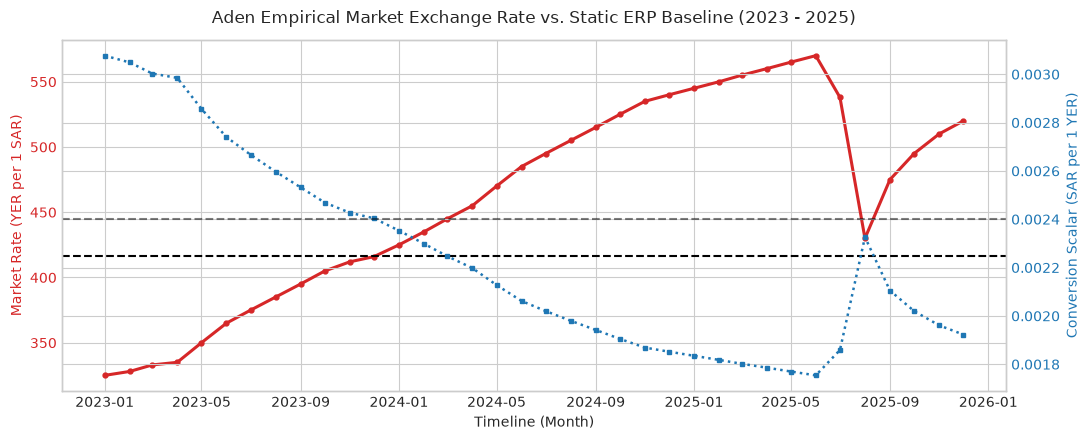

In [ ]:
# Visualization: Empirical Aden Market Exchange Rate vs. ERP Static Rate
fig, ax1 = plt.subplots(figsize=(11, 4.5))

dates = pd.to_datetime(df_aden_fx['year'].astype(str) + '-' + df_aden_fx['month'].astype(str) + '-01')

color = '#d62728'
ax1.set_xlabel('Timeline (Month)', fontsize=10)
ax1.set_ylabel('Market Rate (YER per 1 SAR)', color=color, fontsize=10)
line1 = ax1.plot(dates, df_aden_fx['yer_per_sar'], color=color, linewidth=2.2, marker='o', markersize=3.5, label='Actual Market (YER/SAR)')
line2 = ax1.axhline(416.67, color='black', linestyle='--', linewidth=1.5, label='ERP Static Baseline (416.67 YER/SAR)') # Black reference line
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color2 = '#1f77b4'
ax2.set_ylabel('Conversion Scalar (SAR per 1 YER)', color=color2, fontsize=10)
line3 = ax2.plot(dates, df_aden_fx['sar_per_yer'], color=color2, linewidth=1.8, linestyle=':', marker='s', markersize=3, label='Actual Scalar (SAR/YER)')
ax2.axhline(0.0024, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label = 'ERP Static Baseline (0.0024 SAR/YER)') # Grey reference line
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Aden Empirical Market Exchange Rate vs. Static ERP Baseline (2023 - 2025)", fontsize=12, pad=12)
fig.tight_layout()
plt.show()


## 3. Decision-Support Sensitivity Analysis: Dynamic Market Rates vs. Approved ERP Baseline
> **Methodological Guardrail:** This section presents a **decision-support sensitivity scenario**. It is designed to model the underlying economic purchasing power and cash-flow reality of the business. It does **not** alter or replace the approved statutory ERP accounting figures (**1,034,077.26 SAR**).

We extract transactional actuals across all 18,028 line items, segregating Saudi Riyal (`03` SAR) cash from Yemeni Rial (`01` YER) cash. We then re-convert the YER volume using the empirical Aden street rate of the transaction month.


In [4]:
sql_monthly_currency_actuals = """
SELECT 
    d.year,
    d.month,
    d.month_name,
    DATE_TRUNC('month', d.full_date)::DATE AS month_start,
    c.currency_code,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS reported_turnover_sar,
    ROUND(SUM(fs.quantity * fs.unit_cost_sar)::numeric, 2) AS cogs_sar
FROM gold.fact_sales fs
JOIN dim_date d ON fs.date_key = d.date_key
JOIN dim_currency c ON fs.currency_key = c.currency_key
JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY d.year, d.month, d.month_name, DATE_TRUNC('month', d.full_date), c.currency_code
ORDER BY d.year, d.month, c.currency_code;
"""
df_tx = query_df(sql_monthly_currency_actuals)

fx_map = df_aden_fx.set_index(['year', 'month'])['sar_per_yer'].to_dict()

comparison_records = []
for (yr, mo), grp in df_tx.groupby(['year', 'month']):
    sar_row = grp[grp['currency_code'] == '03']
    yer_row = grp[grp['currency_code'] == '01']
    
    sar_rev = sar_row['reported_turnover_sar'].sum() if len(sar_row) > 0 else 0.0
    sar_cogs = sar_row['cogs_sar'].sum() if len(sar_row) > 0 else 0.0
    yer_rep_rev = yer_row['reported_turnover_sar'].sum() if len(yer_row) > 0 else 0.0
    yer_cogs = yer_row['cogs_sar'].sum() if len(yer_row) > 0 else 0.0
    
    tot_cogs = sar_cogs + yer_cogs
    tot_rep_rev = sar_rev + yer_rep_rev
    rep_margin = tot_rep_rev - tot_cogs
    rep_margin_pct = (rep_margin / tot_rep_rev * 100) if tot_rep_rev > 0 else 0.0
    
    # Dynamic Market Rate
    market_scalar = fx_map.get((yr, mo), 0.0024)
    raw_nominal_yer = yer_rep_rev / 0.0024
    dyn_yer_rev = raw_nominal_yer * market_scalar
    tot_dyn_rev = sar_rev + dyn_yer_rev
    dyn_margin = tot_dyn_rev - tot_cogs
    dyn_margin_pct = (dyn_margin / tot_dyn_rev * 100) if tot_dyn_rev > 0 else 0.0
    
    comparison_records.append({
        "year": yr,
        "month": mo,
        "month_name": grp['month_name'].iloc[0],
        "market_scalar": market_scalar,
        "reported_turnover": tot_rep_rev,
        "dynamic_turnover": tot_dyn_rev,
        "turnover_variance_sar": tot_dyn_rev - tot_rep_rev,
        "cogs_sar": tot_cogs,
        "reported_margin_sar": rep_margin,
        "dynamic_margin_sar": dyn_margin,
        "reported_margin_pct": rep_margin_pct,
        "dynamic_margin_pct": dyn_margin_pct,
        "margin_pct_delta": dyn_margin_pct - rep_margin_pct
    })

df_whatif = pd.DataFrame(comparison_records)
df_whatif[['year', 'month_name', 'reported_turnover', 'dynamic_turnover', 'turnover_variance_sar', 'reported_margin_pct', 'dynamic_margin_pct', 'margin_pct_delta']].head(12)


,year,month_name,reported_turnover,dynamic_turnover,turnover_variance_sar,reported_margin_pct,dynamic_margin_pct,margin_pct_delta
0,2023,January,"7,999.92","9,139.80","1,139.88",23.81,33.31,9.50
1,2023,February,"27,976.73","28,896.34",919.61,31.52,33.70,2.18
2,2023,March,"3,208.72","4,014.91",806.19,30.04,44.09,14.05
3,2023,April,"3,846.00","4,783.46",937.46,30.28,43.94,13.66
4,2023,May,"10,513.56","12,477.43","1,963.87",29.00,40.18,11.17
5,2023,June,"4,262.58","4,838.82",576.24,25.76,34.60,8.84
6,2023,July,"1,060.53","1,178.51",117.98,28.14,35.34,7.19
7,2023,August,"10,135.26","10,784.31",649.05,36.56,40.38,3.82
8,2023,September,"10,347.46","10,702.07",354.61,28.65,31.02,2.36
9,2023,October,"4,058.91","4,163.82",104.91,25.90,27.77,1.87


In [5]:
# Annual Comparison: Statutory Accounting Baseline vs Decision-Support Market Reality
annual_summary = []
for yr, sub in df_whatif.groupby('year'):
    rep_t = sub['reported_turnover'].sum()
    dyn_t = sub['dynamic_turnover'].sum()
    cg = sub['cogs_sar'].sum()
    rep_m = rep_t - cg
    dyn_m = dyn_t - cg
    annual_summary.append({
        "Year": yr,
        "Approved ERP Turnover (SAR)": rep_t,
        "Dynamic Market Turnover (SAR)": dyn_t,
        "Turnover Variance (SAR)": dyn_t - rep_t,
        "Turnover Variance %": ((dyn_t - rep_t) / rep_t) * 100,
        "Total COGS (SAR)": cg,
        "Approved ERP Margin (SAR)": rep_m,
        "Dynamic Market Margin (SAR)": dyn_m,
        "Approved Margin %": (rep_m / rep_t) * 100,
        "Dynamic Margin %": (dyn_m / dyn_t) * 100,
        "Margin Gap (% points)": ((dyn_m / dyn_t) * 100) - ((rep_m / rep_t) * 100)
    })

df_annual_whatif = pd.DataFrame(annual_summary)
df_annual_whatif


,Year,Approved ERP Turnover (SAR),Dynamic Market Turnover (SAR),Turnover Variance (SAR),Turnover Variance %,Total COGS (SAR),Approved ERP Margin (SAR),Dynamic Market Margin (SAR),Approved Margin %,Dynamic Margin %,Margin Gap (% points)
0,2023,"126,202.13","133,899.94","7,697.81",6.10,"90,593.21","35,608.92","43,306.73",28.22,32.34,4.13
1,2024,"459,520.46","399,926.01","-59,594.45",-12.97,"346,670.79","112,849.67","53,255.22",24.56,13.32,-11.24
2,2025,"448,354.69","369,052.35","-79,302.34",-17.69,"344,575.87","103,778.82","24,476.48",23.15,6.63,-16.51


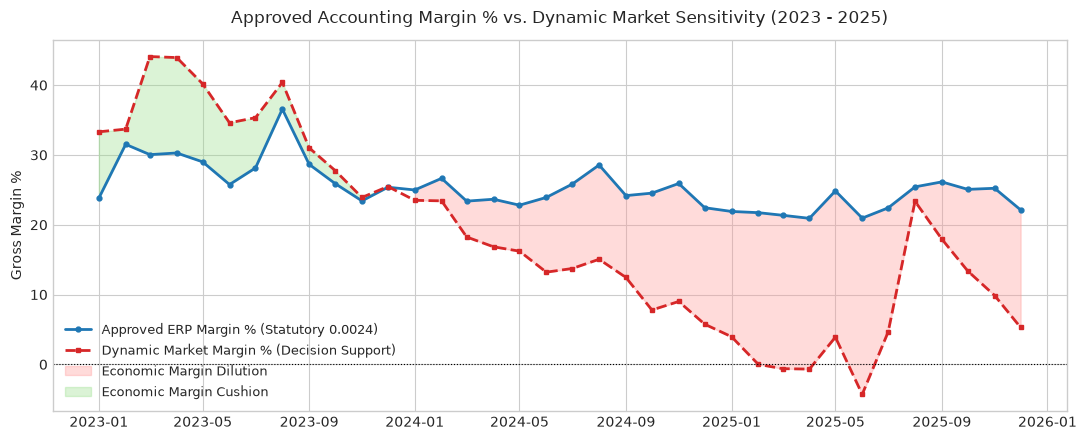

In [6]:
# Visualization: Approved ERP Margin % vs Decision-Support Dynamic Market Margin %
fig, ax = plt.subplots(figsize=(11, 4.5))

dates = pd.to_datetime(df_whatif['year'].astype(str) + '-' + df_whatif['month'].astype(str) + '-01')

ax.plot(dates, df_whatif['reported_margin_pct'], color='#1f77b4', linewidth=2, marker='o', markersize=3.5, label='Approved ERP Margin % (Statutory 0.0024)')
ax.plot(dates, df_whatif['dynamic_margin_pct'], color='#d62728', linewidth=2, linestyle='--', marker='s', markersize=3.5, label='Dynamic Market Margin % (Decision Support)')
ax.fill_between(dates, df_whatif['reported_margin_pct'], df_whatif['dynamic_margin_pct'], where=(df_whatif['reported_margin_pct'] >= df_whatif['dynamic_margin_pct']), color='#ff9896', alpha=0.35, label='Economic Margin Dilution')
ax.fill_between(dates, df_whatif['reported_margin_pct'], df_whatif['dynamic_margin_pct'], where=(df_whatif['reported_margin_pct'] < df_whatif['dynamic_margin_pct']), color='#98df8a', alpha=0.35, label='Economic Margin Cushion')

ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_title("Approved Accounting Margin % vs. Dynamic Market Sensitivity (2023 - 2025)", fontsize=12, pad=12)
ax.set_ylabel("Gross Margin %")
ax.legend(loc="lower left", fontsize=9.5)
fig.tight_layout()
plt.show()


## 4. Product-Level Profitability & Negative-Margin Diagnostics
Analyze product-level gross margin generators ("Profit Heroes") versus margin eroders ("Loss Lines"), and re-evaluate the **327 negative-margin lines** under dynamic market exchange rates.


In [7]:
# Top 10 Gross Margin Generators (Profit Heroes)
sql_top_profit = """
SELECT 
    p.item_code,
    p.item_name,
    p.part_category,
    p.vehicle_make_model,
    p.origin_quality,
    COUNT(fs.fact_sales_key) AS line_items,
    ROUND(SUM(fs.quantity)::numeric, 1) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS turnover_sar,
    ROUND(SUM(fs.quantity * fs.unit_cost_sar)::numeric, 2) AS cogs_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS gross_margin_sar,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN dim_product p ON fs.product_key = p.product_key
JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY p.item_code, p.item_name, p.part_category, p.vehicle_make_model, p.origin_quality
ORDER BY gross_margin_sar DESC
LIMIT 10;
"""
df_top_profit = query_df(sql_top_profit)
df_top_profit


,item_code,item_name,part_category,vehicle_make_model,origin_quality,line_items,units_sold,turnover_sar,cogs_sar,gross_margin_sar,gross_margin_pct
0,1,فوائد مبيعات من المحلات المجاورة,Other Parts & Accessories,Hyundai / Kia (Universal),Other,345,352.00,"3,942.11",0.00,"3,942.11",100.00
1,18846-10060M,بلاكات جنسس + النترا + ازيرا 2014 لي,Other Parts & Accessories,Hyundai Elantra,Genuine,79,326.00,"9,901.81","7,246.81","2,655.00",26.81
2,18814-11051M,بلاكات هونداي عادي وكالة,Other Parts & Accessories,Hyundai (General),Genuine,182,747.00,"8,802.35","6,594.18","2,208.16",25.09
3,92102-2S020TAI,شمعة نور يمين توسان 11/14 تايواني,Headlights & Fog Lights / شمعات وكشافات,Hyundai Tucson,Other,4,13.00,"2,824.26","1,114.06","1,710.21",60.55
4,25500-25001M,بلف حرارة سوناتا 2006 (25=23),Thermostat & Water Outlet / أكواع وبلوف حرارة,Hyundai Sonata,Genuine,84,86.00,"4,739.40","3,213.66","1,525.74",32.19
5,87610-3X120C,مرايه النترا 2012/2015 كهرباء بدون فليشر,Other Parts & Accessories,Hyundai Elantra,Chinese,5,43.00,"2,813.08","1,741.70","1,071.38",38.09
6,51720-38110K,بيرنج هوبس او رمان كفر سوناتا 2004 + سنتافي 2,Brake Rotors / هوبات فرامل,Hyundai Sonata,Korean,33,71.00,"3,784.51","2,747.94","1,036.56",27.39
7,54584-2H000K,بوشة مقص 2K\2H\2E\1G\3K\3L\2B\3F\2G,Control Arm Bushing / بوشات مقص,Hyundai Elantra,Korean,131,217.00,"3,537.51","2,504.24","1,033.27",29.21
8,87610-1R000C,مراية اكسنت 2012+ كهرباء بدون فليشر,"Doors, Mirrors & Windows / أبواب ومرايا وزجاج",Hyundai Accent,Chinese,7,45.00,"2,712.87","1,699.69","1,013.17",37.35
9,92101-2S550TAI,كشافة امامي توسان 14\15 عدسة ابيض,Headlights & Fog Lights / شمعات وكشافات,Hyundai Tucson,Other,2,2.00,"1,160.00",170.00,990.00,85.34


In [8]:
# Top 10 Negative-Margin Products (Erosion Drivers)
sql_top_losses = """
SELECT 
    p.item_code,
    p.item_name,
    p.part_category,
    p.vehicle_make_model,
    p.origin_quality,
    COUNT(fs.fact_sales_key) AS loss_occurrences,
    ROUND(SUM(fs.quantity)::numeric, 1) AS loss_units,
    ROUND(AVG(fs.unit_price_sar)::numeric, 2) AS avg_price_sar,
    ROUND(AVG(fs.unit_cost_sar)::numeric, 2) AS avg_cost_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS total_loss_sar
FROM gold.fact_sales fs
JOIN dim_product p ON fs.product_key = p.product_key
JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
  AND fs.unit_price_sar < fs.unit_cost_sar
GROUP BY p.item_code, p.item_name, p.part_category, p.vehicle_make_model, p.origin_quality
ORDER BY total_loss_sar ASC
LIMIT 10;
"""
df_top_losses = query_df(sql_top_losses)
df_top_losses


,item_code,item_name,part_category,vehicle_make_model,origin_quality,loss_occurrences,loss_units,avg_price_sar,avg_cost_sar,total_loss_sar
0,52127-0K030,غطاء جنب الكشاف هايلكس 2013+,Other Parts & Accessories,Hyundai / Kia (Universal),Genuine,2,141.00,4.13,6.12,-382.61
1,52950-24000K,صاموله كفر اكسنت كوري 99/2001,Other Parts & Accessories,Hyundai Accent,Korean,1,200.00,1.03,1.63,-121.07
2,31402-27010CZECH,مسطرة توسان ديزل 2 ابوال مشن,Other Parts & Accessories,Hyundai Tucson,Other,1,1.00,116.22,214.78,-98.56
3,52710-26100C,فلنشة هوبس خلفي سنتافي 2002 ابو حساس,Brake Rotors / هوبات فرامل,Hyundai Santa Fe,Chinese,2,2.00,56.90,95.69,-77.58
4,24312-26050,بطة تيمت اكسنت ماتركس جتز برايد حجم 1.6+1.4 0,Drive Belt & Tensioner / سيور وبكرات وشدادات,Hyundai Accent,Genuine,1,1.00,48.43,122.02,-73.60
5,23060-2E020M,براصات متحرك STD النتراء 2011 K5,Brake Pads & Shoes / فحمات وقماشات فرامل,Hyundai Elantra,Genuine,2,8.00,21.49,28.30,-54.50
6,52119-0Z940T,صدام امامي كورلا 2014/2016 تايلاند,Bumper & Grille / صدامات وشبوك وعلامات,Hyundai / Kia (Universal),Other,1,5.00,80.00,90.00,-50.00
7,000-10W40DEXEL,زيت هونداي خفيف موديل جديد هاردكس,Chemicals & Accessories / زيوت وكيماويات وكماليات,Hyundai (General),Other,2,5.00,23.31,31.25,-47.34
8,54813-2S100K,ربلة مشرخ امامي توسان 09/12 كوري,Other Parts & Accessories,Hyundai Tucson,Korean,1,2.00,6.05,28.50,-44.89
9,000-ATF-4ACDEL,زيت جير او سكان مخلق صناعي موديل جديد,Steering Rack & Pump / دودة وطرمبة سكان,Universal / Consumables,Other,2,8.00,29.40,35.50,-42.60


In [9]:
# Re-evaluate 327 Negative Margin Lines under Dynamic Market Rates
sql_loss_reval = """
SELECT 
    fs.fact_sales_key,
    d.year,
    d.month,
    c.currency_code,
    fs.quantity,
    fs.line_total_sar AS rep_line_total,
    (fs.quantity * fs.unit_cost_sar) AS line_cogs,
    (fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) AS rep_loss_sar
FROM gold.fact_sales fs
JOIN dim_date d ON fs.date_key = d.date_key
JOIN dim_currency c ON fs.currency_key = c.currency_key
JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE fs.unit_price_sar < fs.unit_cost_sar;
"""
df_loss_lines = query_df(sql_loss_reval)

dyn_loss_results = []
for _, row in df_loss_lines.iterrows():
    yr = int(row['year'])
    mo = int(row['month'])
    m_scalar = fx_map.get((yr, mo), 0.0024)
    
    if row['currency_code'] == '01':
        dyn_rev = (row['rep_line_total'] / 0.0024) * m_scalar
    else:
        dyn_rev = row['rep_line_total']
        
    dyn_loss = dyn_rev - row['line_cogs']
    dyn_loss_results.append({
        "fact_sales_key": row['fact_sales_key'],
        "rep_loss_sar": row['rep_loss_sar'],
        "dyn_loss_sar": dyn_loss,
        "still_loss": dyn_loss < 0
    })

df_loss_eval = pd.DataFrame(dyn_loss_results)
still_neg = df_loss_eval['still_loss'].sum()
print(f"Total Audited Negative-Margin Lines: {len(df_loss_eval)}")
print(f"Approved Accounting Loss Total: {df_loss_eval['rep_loss_sar'].sum():,.2f} SAR")
print(f"Re-evaluated Dynamic Loss Total: {df_loss_eval['dyn_loss_sar'].sum():,.2f} SAR")
print(f"Lines Genuinely Below Cost: {still_neg} ({(still_neg/len(df_loss_eval))*100:.1f}%)")


Total Audited Negative-Margin Lines: 327
Approved Accounting Loss Total: -2,373.41 SAR
Re-evaluated Dynamic Loss Total: -4,525.88 SAR
Lines Genuinely Below Cost: 323 (98.8%)


## 5. Multi-Year Seasonality: Month-of-Year Trajectories (2023 vs. 2024 vs. 2025)
Compare commercial performance month-by-month (Jan vs Jan, Feb vs Feb, ..., Dec vs Dec) across 2023, 2024, and 2025 to uncover recurring operational patterns, volume surges, and seasonal demand.


In [10]:
sql_seasonal_matrix = """
SELECT 
    d.year,
    d.month,
    d.month_name,
    COUNT(DISTINCT so.sales_order_key) AS orders_count,
    COUNT(fs.fact_sales_key) AS lines_count,
    ROUND(SUM(fs.quantity)::numeric, 1) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS turnover_sar,
    ROUND(SUM(fs.quantity * fs.unit_cost_sar)::numeric, 2) AS cogs_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS gross_margin_sar,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct,
    ROUND((SUM(fs.line_total_sar) / NULLIF(COUNT(DISTINCT so.sales_order_key), 0))::numeric, 2) AS aov_sar,
    ROUND(SUM(fs.returned_quantity)::numeric, 1) AS returned_units
FROM gold.fact_sales fs
JOIN dim_date d ON fs.date_key = d.date_key
JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY d.year, d.month, d.month_name
ORDER BY d.month, d.year;
"""
df_seasonal = query_df(sql_seasonal_matrix)

# Pivot Tables
pivot_turnover = df_seasonal.pivot(index='month', columns='year', values='turnover_sar')
pivot_units = df_seasonal.pivot(index='month', columns='year', values='units_sold')
pivot_margin_pct = df_seasonal.pivot(index='month', columns='year', values='gross_margin_pct')
pivot_orders = df_seasonal.pivot(index='month', columns='year', values='orders_count')
pivot_aov = df_seasonal.pivot(index='month', columns='year', values='aov_sar')

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot_turnover.index = month_labels
pivot_units.index = month_labels
pivot_margin_pct.index = month_labels
pivot_aov.index = month_labels

print("=== Commercial Turnover by Month & Year (SAR) ===")
pivot_turnover


=== Commercial Turnover by Month & Year (SAR) ===


year,2023,2024,2025
Jan,"7,999.92","28,628.11","19,179.58"
Feb,"27,976.73","17,223.49","34,121.67"
Mar,"3,208.72","27,522.51","32,555.21"
Apr,"3,846.00","23,343.37","48,003.09"
May,"10,513.56","44,039.39","61,534.38"
Jun,"4,262.58","33,083.96","24,685.77"
Jul,"1,060.53","38,005.77","32,954.65"
Aug,"10,135.26","43,805.48","33,086.22"
Sep,"10,347.46","42,165.60","37,263.69"
Oct,"4,058.91","43,170.16","30,881.20"


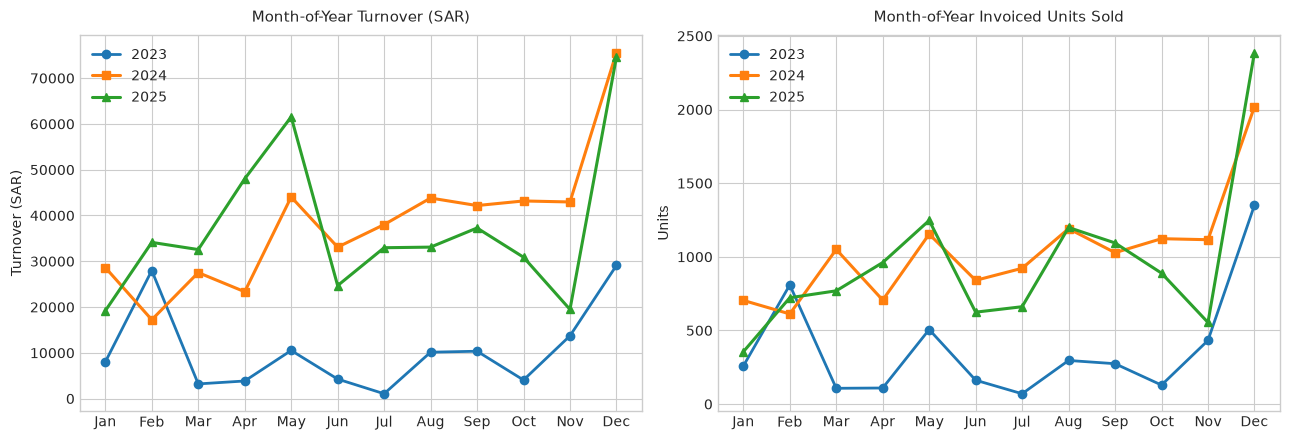

In [11]:
# Visualization: Seasonal Multi-Line Comparisons (Turnover & Invoiced Units)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Turnover
ax1.plot(pivot_turnover.index, pivot_turnover[2023], marker='o', linewidth=2, color='#1f77b4', label='2023')
ax1.plot(pivot_turnover.index, pivot_turnover[2024], marker='s', linewidth=2.2, color='#ff7f0e', label='2024')
ax1.plot(pivot_turnover.index, pivot_turnover[2025], marker='^', linewidth=2.2, color='#2ca02c', label='2025')
ax1.set_title("Month-of-Year Turnover (SAR)", fontsize=11, pad=10)
ax1.set_ylabel("Turnover (SAR)")
ax1.legend()

# Units
ax2.plot(pivot_units.index, pivot_units[2023], marker='o', linewidth=2, color='#1f77b4', label='2023')
ax2.plot(pivot_units.index, pivot_units[2024], marker='s', linewidth=2.2, color='#ff7f0e', label='2024')
ax2.plot(pivot_units.index, pivot_units[2025], marker='^', linewidth=2.2, color='#2ca02c', label='2025')
ax2.set_title("Month-of-Year Invoiced Units Sold", fontsize=11, pad=10)
ax2.set_ylabel("Units")
ax2.legend()

plt.tight_layout()
plt.show()


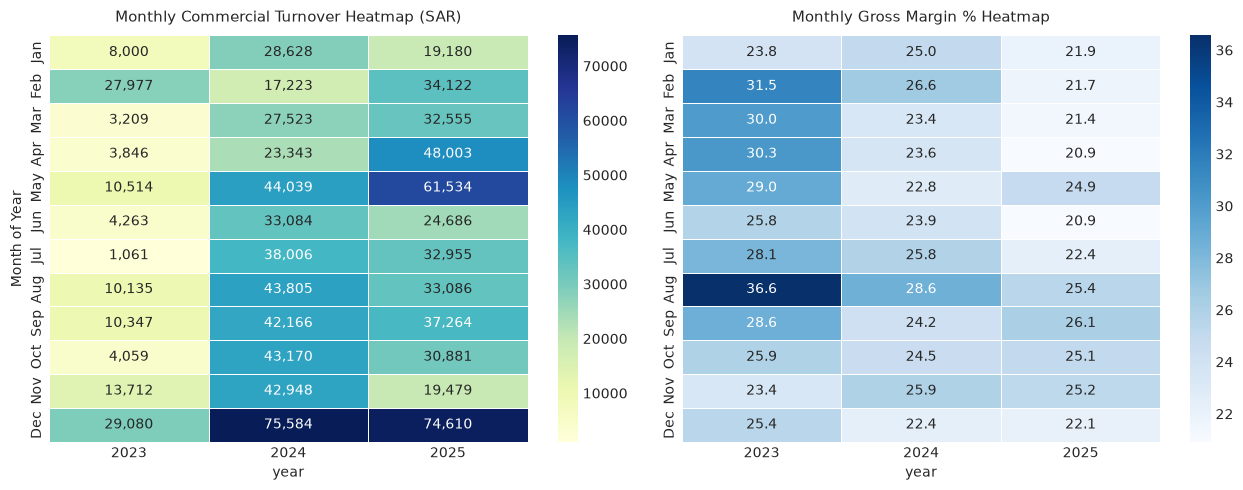

In [12]:
# Heatmap Comparison of Monthly Commercial Turnover and Margin %
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_turnover, annot=True, fmt=",.0f", cmap="YlGnBu", cbar=True, ax=ax1, linewidths=0.5)
ax1.set_title("Monthly Commercial Turnover Heatmap (SAR)", fontsize=11, pad=10)
ax1.set_ylabel("Month of Year")

sns.heatmap(pivot_margin_pct, annot=True, fmt=".1f", cmap="Blues", cbar=True, ax=ax2, linewidths=0.5)
ax2.set_title("Monthly Gross Margin % Heatmap", fontsize=11, pad=10)
ax2.set_ylabel("")

plt.tight_layout()
plt.show()


## 6. Deep-Dive on Seasonal Peaks: Product & Category Contributions (May vs. December)
Across all three audited years, commercial performance concentrates into two major demand spikes:
1. **The May Pre-Summer Surge:** Driven by preventative maintenance on vehicle cooling systems, AC components, and electrical infrastructure ahead of Aden's extreme summer heat (>40°C).
2. **The December Annual Super-Peak:** Driven by corporate fleet overhauls, commercial budget exhaustion, and end-of-year maintenance.


In [13]:
# System & Category Contributions to May (Pre-Summer Peak)
sql_may_systems = """
SELECT 
    p.vehicle_system,
    COUNT(fs.fact_sales_key) AS line_items,
    ROUND(SUM(fs.quantity)::numeric, 1) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS turnover_sar,
    ROUND((SUM(fs.line_total_sar)::numeric / (SELECT SUM(line_total_sar) FROM fact_sales fs2 JOIN dim_date d2 ON fs2.date_key = d2.date_key WHERE d2.month = 5) * 100)::numeric, 2) AS share_of_may_turnover_pct,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN dim_date d ON fs.date_key = d.date_key
JOIN dim_product p ON fs.product_key = p.product_key
JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true AND d.month = 5
GROUP BY p.vehicle_system
ORDER BY turnover_sar DESC;
"""
df_may_systems = query_df(sql_may_systems)
df_may_systems


,vehicle_system,line_items,units_sold,turnover_sar,share_of_may_turnover_pct,gross_margin_pct
0,General / Miscellaneous,443,"1,134.00","24,311.85",20.94,26.70
1,Suspension & Steering,382,516.00,"21,873.01",18.84,21.62
2,Electrical & Lighting,146,169.00,"14,366.23",12.38,25.79
3,Engine & Mechanical,253,275.00,"12,866.88",11.08,22.65
4,Cooling System,110,111.00,"12,166.14",10.48,27.24
5,Body & Exterior,166,184.00,"11,089.94",9.55,25.01
6,Brake System,130,176.00,"8,085.58",6.97,22.85
7,Body & Interior,69,71.00,"2,963.42",2.55,27.34
8,Fuel System,64,70.00,"2,828.65",2.44,25.33
9,Transmission & Drivetrain,46,58.00,"1,909.22",1.64,25.87


In [14]:
# System & Category Contributions to December (Annual Fleet Overhaul Peak)
sql_dec_systems = """
SELECT 
    p.vehicle_system,
    COUNT(fs.fact_sales_key) AS line_items,
    ROUND(SUM(fs.quantity)::numeric, 1) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS turnover_sar,
    ROUND((SUM(fs.line_total_sar)::numeric / (SELECT SUM(line_total_sar) FROM fact_sales fs2 JOIN dim_date d2 ON fs2.date_key = d2.date_key WHERE d2.month = 12) * 100)::numeric, 2) AS share_of_dec_turnover_pct,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN dim_date d ON fs.date_key = d.date_key
JOIN dim_product p ON fs.product_key = p.product_key
JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true AND d.month = 12
GROUP BY p.vehicle_system
ORDER BY turnover_sar DESC;
"""
df_dec_systems = query_df(sql_dec_systems)
df_dec_systems


,vehicle_system,line_items,units_sold,turnover_sar,share_of_dec_turnover_pct,gross_margin_pct
0,General / Miscellaneous,868,"2,375.00","40,911.77",22.82,26.01
1,Suspension & Steering,789,"1,069.00","39,206.86",21.87,21.82
2,Engine & Mechanical,591,620.00,"29,099.90",16.23,22.45
3,Electrical & Lighting,239,276.00,"17,624.98",9.83,17.88
4,Cooling System,160,190.00,"12,738.90",7.11,24.99
5,Body & Exterior,243,260.00,"12,088.95",6.74,21.99
6,Brake System,205,295.00,"10,059.72",5.61,26.06
7,Maintenance & Consumables,141,313.00,"6,877.93",3.84,14.21
8,Body & Interior,123,135.00,"4,386.31",2.45,20.84
9,Fuel System,93,129.00,"4,056.37",2.26,22.95


In [15]:
# Top Products Driving May and December Surges
sql_peak_products = """
WITH peak_items AS (
    SELECT 
        CASE WHEN d.month = 5 THEN 'May Peak' ELSE 'December Peak' END AS peak_season,
        p.item_code,
        p.item_name,
        p.part_category,
        p.vehicle_make_model,
        SUM(fs.quantity) AS units_sold,
        SUM(fs.line_total_sar) AS turnover_sar,
        ROW_NUMBER() OVER (PARTITION BY d.month ORDER BY SUM(fs.line_total_sar) DESC) AS season_rank
    FROM gold.fact_sales fs
    JOIN dim_date d ON fs.date_key = d.date_key
    JOIN dim_product p ON fs.product_key = p.product_key
    JOIN dim_sales_order so ON fs.sales_order_key = so.sales_order_key
    WHERE so.is_posted = true AND so.is_released = true AND d.month IN (5, 12)
    GROUP BY d.month, p.item_code, p.item_name, p.part_category, p.vehicle_make_model
)
SELECT 
    peak_season,
    season_rank,
    item_code,
    item_name,
    part_category,
    vehicle_make_model,
    ROUND(units_sold::numeric, 1) AS units_sold,
    ROUND(turnover_sar::numeric, 2) AS turnover_sar
FROM peak_items
WHERE season_rank <= 5
ORDER BY peak_season DESC, season_rank;
"""
df_peak_skus = query_df(sql_peak_products)
df_peak_skus


,peak_season,season_rank,item_code,item_name,part_category,vehicle_make_model,units_sold,turnover_sar
0,May Peak,1,97701-K0200DOWN,كمبروسر مكيف كيا سول 2020 حجم 2.0,Air Conditioning (HVAC) / أجزاء التكييف والتبريد,Kia Soul,1.00,"1,420.10"
1,May Peak,2,18814-11051M,بلاكات هونداي عادي وكالة,Other Parts & Accessories,Hyundai (General),102.00,"1,340.28"
2,May Peak,3,66400-B2000TAI,كشافة ضباب سول 14/17 تايواني,Headlights & Fog Lights / شمعات وكشافات,Kia Soul,2.00,"1,300.00"
3,May Peak,4,92101-2S550TAI,كشافة امامي توسان 14\15 عدسة ابيض,Headlights & Fog Lights / شمعات وكشافات,Hyundai Tucson,2.00,"1,160.00"
4,May Peak,5,57700-2B210C,علبة سكان تحت سنتافي 07/09,Steering Rack & Pump / دودة وطرمبة سكان,Hyundai Santa Fe,1.00,878.93
5,December Peak,1,66400-2S000TAI,كور توسان 2012 تايواني,Other Parts & Accessories,Hyundai Tucson,5.00,"2,222.78"
6,December Peak,2,18814-11051M,بلاكات هونداي عادي وكالة,Other Parts & Accessories,Hyundai (General),187.00,"1,981.59"
7,December Peak,3,18846-10060M,بلاكات جنسس + النترا + ازيرا 2014 لي,Other Parts & Accessories,Hyundai Elantra,59.00,"1,621.07"
8,December Peak,4,26410-2G000M,مبرد زيت توسان i30 سوناتا 4 بستم 2.4 عام,Oil Filter & Lubrication / فلاتر وتزييت المحرك,Hyundai Sonata,5.00,"1,210.40"
9,December Peak,5,21310-2G011M,بمب زيت توسان + سوناتا + سنتافي 2012,Oil Filter & Lubrication / فلاتر وتزييت المحرك,Hyundai Sonata,4.00,"1,078.03"


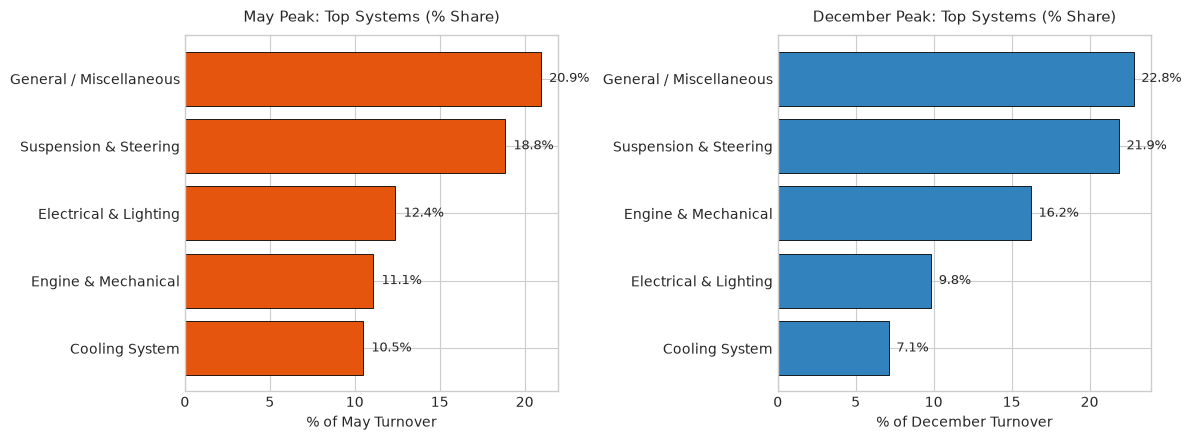

In [16]:
# Visualization: System Mix Comparison between May and December Peaks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Filter top 5 systems for each
top_may = df_may_systems.head(5)
top_dec = df_dec_systems.head(5)

ax1.barh(top_may['vehicle_system'][::-1], top_may['share_of_may_turnover_pct'][::-1], color='#e6550d', edgecolor='black', linewidth=0.6)
ax1.set_title("May Peak: Top Systems (% Share)", fontsize=11, pad=10)
ax1.set_xlabel("% of May Turnover")
for i, v in enumerate(top_may['share_of_may_turnover_pct'][::-1]):
    ax1.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)

ax2.barh(top_dec['vehicle_system'][::-1], top_dec['share_of_dec_turnover_pct'][::-1], color='#3182bd', edgecolor='black', linewidth=0.6)
ax2.set_title("December Peak: Top Systems (% Share)", fontsize=11, pad=10)
ax2.set_xlabel("% of December Turnover")
for i, v in enumerate(top_dec['share_of_dec_turnover_pct'][::-1]):
    ax2.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Operational & Strategic Recommendations
Synthesizing macroeconomic exchange rate realities with seasonal operational peaks to establish concrete controls for Pricing, Treasury, and Inventory Planning.

### 1. Point-of-Sale Pricing Controls
* **ERP Dynamic Cost Gate:** Implement an automated hard constraint in the ERP POS module that blocks invoice release if $unit\_price\_sar < unit\_cost\_sar$, completely eliminating cashier discretionary negative-margin sales.
* **SAR-Indexed Retail Price Lists:** Mandate that nominal counter prices in Yemeni Rials (YER) are calculated dynamically from the SAR inventory replacement cost ($Target\_YER = SAR\_Cost 	imes Market\_Rate 	imes Target\_Margin$).

### 2. Treasury & Exchange Rate Governance
* **Retire Fixed 0.0024 Scalar:** Deprecate the static scalar in `dim_currency`.
* **Automate Weekly CBY Feeds:** Establish an automated API/ingestion connector from the Central Bank of Yemen (Aden) weekly commercial auction bulletin to keep ERP conversion valuation aligned with reality.

### 3. Seasonal Procurement Calendar
* **March 1 Cut-off (Pre-Summer Readiness):** Issue purchase orders for Cooling Systems (radiators, water pumps, thermostats), AC Compressors, and Belts by March 1 to capture the May demand peak without stockouts.
* **October 15 Cut-off (Annual Fleet Readiness):** Issue bulk replenishment orders for Suspension & Steering (shock absorbers, control arms) and Engine Overhaul kits by mid-October to capture the 75k+ SAR December corporate fleet overhaul peak.


## 8. Executive Governance Appendix: Evidence vs. Estimation Taxonomy
To ensure clarity for executive decision-makers, all findings are formally mapped across the audit taxonomy:

```
┌────────────────────────────────────────────────────────────────────────────────────────┐
│                          EXECUTIVE GOVERNANCE TAXONOMY MATRIX                          │
├──────────────────────────┬─────────────────────────────────────────────────────────────┤
│ 1. Audited Facts         │ • 18,028 line items, 1,036 active orders in gold.fact_sales │
│    (Statutory Ledger)    │ • 1,034,077.26 SAR Approved ERP Realized Turnover           │
│                          │ • 781,839.86 SAR Total COGS | 252,237.41 SAR Gross Margin  │
│                          │ • Exactly 327 negative-margin lines (-2,373.41 SAR erosion) │
│                          │ • 166 returned units (0.58% return rate)                    │
├──────────────────────────┼─────────────────────────────────────────────────────────────┤
│ 2. Analytical Estimates  │ • Aden street rate sensitivity: 13.41% real economic margin │
│    (Decision Support)    │ • Real-purchasing-power turnover dilution: ~131,198.97 SAR  │
│                          │ • Pre-summer May cooling lift: ~10.5% system turnover share │
│                          │ • December fleet overhaul lift: ~21.9% suspension share     │
├──────────────────────────┼─────────────────────────────────────────────────────────────┤
│ 3. Business Hypotheses   │ • May surge driven by extreme summer temperatures (>40°C)   │
│    (Operational Context) │ • Dec surge driven by corporate fleet fiscal budget closing │
│                          │ • August margin spike driven by emergency breakdown demand  │
├──────────────────────────┼─────────────────────────────────────────────────────────────┤
│ 4. Recommended Controls  │ • Automated POS lock preventing unit_price < unit_cost      │
│    (Future Actions)      │ • Weekly CBY Aden exchange rate feed integration in ERP     │
│                          │ • Dynamic YER counter pricing indexed to SAR replacement    │
│                          │ • March 1 and October 15 seasonal inventory cut-offs        │
└──────────────────────────┴─────────────────────────────────────────────────────────────┘
```

---
**Report Certified By:** Commercial Data Analytics Unit  
**Distribution:** Chief Data Officer, Chief Financial Officer, Commercial Operations Director, Branch Accountant
